# 06 — Synthesis and Poster Figures

**Author:** Sharon Christa
**Date:** April 2026  
**Purpose:** Combine all findings from notebooks 01-05 into poster-ready figures and a headline numbers table.

### What this notebook produces

1. **`06_headline_numbers.csv`** — single clean table of the 15 most important statistics across all analyses
2. **`06_poster_dashboard.png`** — 4-panel composite figure: LULC change | LST trends | NDBI correlation | LCZ thermal ranking
3. **`06_two_cities_story.png`** — single-panel conceptual figure contrasting Dar's informal-settlement heat trap with Singapore's high-rise heat dome
4. **`06_cooling_benefit.png`** — clean policy-facing figure showing cooling benefit of trees in both cities

### Reading the inputs

All data comes from CSVs produced by notebooks 01-05:
- `01` outputs aren't CSV — we re-type the LULC percentages by hand (they're small and fixed)
- `03_lst_trends.csv` — warming trends from MODIS time series
- `03_diurnal_range.csv` — day-night spread
- `04b_correlations.csv` — NDVI/NDBI/MNDWI correlations (land-only)
- `04b_lst_per_class.csv` — mean LST per Dynamic World class
- `05_lst_per_lcz.csv` — mean LST per LCZ type (the deepest result)


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

In [2]:
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titleweight'] = 'bold'

# Paths
TABLES = Path('../outputs/tables')
FIGURES = Path('../outputs/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

# Colour palette used consistently across the project
COLORS = {
    'Dar es Salaam': '#B65D2E',  # terracotta
    'Singapore':     '#2E7D5B',  # forest green
}

## 2. Load all intermediate results

In [3]:
trends = pd.read_csv(TABLES / '03_lst_trends.csv')
diurnal = pd.read_csv(TABLES / '03_diurnal_range.csv')
corr = pd.read_csv(TABLES / '04b_correlations.csv')
lulc_class = pd.read_csv(TABLES / '04b_lst_per_class.csv')
lcz = pd.read_csv(TABLES / '05_lst_per_lcz.csv')

print('trends:    ', trends.shape, trends.columns.tolist())
print('diurnal:   ', diurnal.shape, diurnal.columns.tolist())
print('corr:      ', corr.shape, corr.columns.tolist())
print('lulc_class:', lulc_class.shape, lulc_class.columns.tolist())
print('lcz:       ', lcz.shape, lcz.columns.tolist())

trends:     (4, 6) ['city', 'tod', 'slope_C_per_decade', 'intercept', 'r_squared', 'p_value']
diurnal:    (10, 5) ['city', 'year', 'day', 'night', 'diurnal_range']
corr:       (10, 9) ['index', 'r', 'r_squared', 'p_value', 'slope', 'intercept', 'n', 'city', 'scope']
lulc_class: (16, 6) ['class', 'mean', 'std', 'count', 'ci95', 'city']
lcz:        (24, 7) ['lcz', 'label', 'mean', 'std', 'count', 'ci95', 'city']


## 3. LULC composition (from notebook 01, entered by hand)

The LULC results from notebook 01 are small and we can retype them. If you want to automate this, save a CSV in notebook 01 named `01_lulc_composition.csv` and read it here.

In [4]:
# From notebook 01 — Dynamic World composition of each city
lulc_data = [
    # Dar es Salaam
    {'city':'Dar es Salaam','year':2020,'class':'built','pct':57.62},
    {'city':'Dar es Salaam','year':2020,'class':'trees','pct':16.67},
    {'city':'Dar es Salaam','year':2020,'class':'shrub_and_scrub','pct':15.62},
    {'city':'Dar es Salaam','year':2020,'class':'flooded_vegetation','pct':3.99},
    {'city':'Dar es Salaam','year':2020,'class':'grass','pct':2.76},
    {'city':'Dar es Salaam','year':2020,'class':'crops','pct':1.90},
    {'city':'Dar es Salaam','year':2020,'class':'water','pct':0.89},
    {'city':'Dar es Salaam','year':2020,'class':'bare','pct':0.55},
    {'city':'Dar es Salaam','year':2025,'class':'built','pct':61.15},
    {'city':'Dar es Salaam','year':2025,'class':'trees','pct':14.20},
    {'city':'Dar es Salaam','year':2025,'class':'shrub_and_scrub','pct':16.75},
    {'city':'Dar es Salaam','year':2025,'class':'flooded_vegetation','pct':2.92},
    {'city':'Dar es Salaam','year':2025,'class':'grass','pct':2.14},
    {'city':'Dar es Salaam','year':2025,'class':'crops','pct':1.30},
    {'city':'Dar es Salaam','year':2025,'class':'water','pct':0.82},
    {'city':'Dar es Salaam','year':2025,'class':'bare','pct':0.73},
    # Singapore
    {'city':'Singapore','year':2020,'class':'built','pct':55.75},
    {'city':'Singapore','year':2020,'class':'trees','pct':26.57},
    {'city':'Singapore','year':2020,'class':'water','pct':8.79},
    {'city':'Singapore','year':2020,'class':'grass','pct':4.31},
    {'city':'Singapore','year':2020,'class':'bare','pct':1.73},
    {'city':'Singapore','year':2020,'class':'flooded_vegetation','pct':1.31},
    {'city':'Singapore','year':2020,'class':'crops','pct':0.96},
    {'city':'Singapore','year':2020,'class':'shrub_and_scrub','pct':0.57},
    {'city':'Singapore','year':2025,'class':'built','pct':53.81},
    {'city':'Singapore','year':2025,'class':'trees','pct':29.15},
    {'city':'Singapore','year':2025,'class':'water','pct':8.81},
    {'city':'Singapore','year':2025,'class':'grass','pct':3.30},
    {'city':'Singapore','year':2025,'class':'flooded_vegetation','pct':2.02},
    {'city':'Singapore','year':2025,'class':'bare','pct':1.54},
    {'city':'Singapore','year':2025,'class':'crops','pct':0.62},
    {'city':'Singapore','year':2025,'class':'shrub_and_scrub','pct':0.69},
]
lulc = pd.DataFrame(lulc_data)

# Compute change 2020 → 2025 per class per city
pivot = lulc.pivot_table(index=['city','class'], columns='year', values='pct').reset_index()
pivot['delta_pp'] = pivot[2025] - pivot[2020]
print('\nLULC change, percentage points (2020 → 2025):')
print(pivot[['city','class',2020,2025,'delta_pp']].round(2).to_string(index=False))


LULC change, percentage points (2020 → 2025):
         city              class  2020  2025  delta_pp
Dar es Salaam               bare  0.55  0.73      0.18
Dar es Salaam              built 57.62 61.15      3.53
Dar es Salaam              crops  1.90  1.30     -0.60
Dar es Salaam flooded_vegetation  3.99  2.92     -1.07
Dar es Salaam              grass  2.76  2.14     -0.62
Dar es Salaam    shrub_and_scrub 15.62 16.75      1.13
Dar es Salaam              trees 16.67 14.20     -2.47
Dar es Salaam              water  0.89  0.82     -0.07
    Singapore               bare  1.73  1.54     -0.19
    Singapore              built 55.75 53.81     -1.94
    Singapore              crops  0.96  0.62     -0.34
    Singapore flooded_vegetation  1.31  2.02      0.71
    Singapore              grass  4.31  3.30     -1.01
    Singapore    shrub_and_scrub  0.57  0.69      0.12
    Singapore              trees 26.57 29.15      2.58
    Singapore              water  8.79  8.81      0.02


## 4. Compile headline numbers table

Every key statistic from the project in one place.

In [5]:
def get_corr(city, index, scope='land'):
    s = corr[(corr.city == city) & (corr['index'] == index) & (corr.scope == scope)]
    return s['r'].iloc[0] if len(s) else None


def get_trend(city_code, tod):
    s = trends[(trends.city == city_code) & (trends.tod == tod)]
    return s['slope_C_per_decade'].iloc[0] if len(s) else None


def get_lcz_mean(city, label):
    s = lcz[(lcz.city == city) & (lcz.label == label)]
    return s['mean'].iloc[0] if len(s) else None


def get_lulc_delta(city, cls):
    s = pivot[(pivot.city == city) & (pivot['class'] == cls)]
    return s['delta_pp'].iloc[0] if len(s) else None


headline = []
for city, city_code in [('Dar es Salaam','dar'), ('Singapore','sgp')]:
    # LULC
    h = {'city': city}
    h['built_pct_2020'] = lulc.query('city == @city and year == 2020 and `class` == "built"')['pct'].iloc[0]
    h['built_pct_2025'] = lulc.query('city == @city and year == 2025 and `class` == "built"')['pct'].iloc[0]
    h['built_delta_pp'] = get_lulc_delta(city, 'built')
    h['trees_delta_pp'] = get_lulc_delta(city, 'trees')

    # LST trends
    h['day_trend_C_per_decade'] = get_trend(city_code, 'day')
    h['night_trend_C_per_decade'] = get_trend(city_code, 'night')

    # Correlations (land only)
    h['NDVI_r'] = get_corr(city, 'NDVI')
    h['NDBI_r'] = get_corr(city, 'NDBI')

    # LCZ extremes
    sub = lcz[lcz.city == city].sort_values('mean', ascending=False)
    if len(sub):
        h['warmest_LCZ'] = sub.iloc[0]['label']
        h['warmest_LCZ_degC'] = sub.iloc[0]['mean']
        h['coolest_LCZ'] = sub.iloc[-1]['label']
        h['coolest_LCZ_degC'] = sub.iloc[-1]['mean']
        h['intra_city_range_degC'] = h['warmest_LCZ_degC'] - h['coolest_LCZ_degC']

    # Cooling benefit of dense trees
    trees = get_lcz_mean(city, 'Dense trees')
    built_types = ['Compact HR', 'Compact MR', 'Compact LR']
    built_means = [get_lcz_mean(city, t) for t in built_types]
    built_means = [m for m in built_means if m is not None]
    if trees and built_means:
        h['compact_built_avg_degC'] = np.mean(built_means)
        h['dense_trees_degC'] = trees
        h['cooling_benefit_degC'] = np.mean(built_means) - trees

    headline.append(h)

headline_df = pd.DataFrame(headline).set_index('city').T
print('=' * 80)
print('HEADLINE NUMBERS — the entire project in one table')
print('=' * 80)
print(headline_df.round(2).to_string())

headline_df.to_csv(FIGURES.parent / 'tables' / '06_headline_numbers.csv')
print(f'\nSaved: {(FIGURES.parent / "tables" / "06_headline_numbers.csv").resolve()}')

HEADLINE NUMBERS — the entire project in one table
city                     Dar es Salaam       Singapore
built_pct_2020                   57.62           55.75
built_pct_2025                   61.15           53.81
built_delta_pp                    3.53           -1.94
trees_delta_pp                   -2.47            2.58
day_trend_C_per_decade        -1.35311       -0.757447
night_trend_C_per_decade      0.670966        0.607536
NDVI_r                       -0.440237       -0.614779
NDBI_r                        0.308994        0.680086
warmest_LCZ                Lightweight  Heavy industry
warmest_LCZ_degC             39.125004       43.981593
coolest_LCZ                      Water           Water
coolest_LCZ_degC             29.734131       31.954771
intra_city_range_degC         9.390873       12.026822
compact_built_avg_degC       38.205356        42.42853
dense_trees_degC              30.39699       33.939114
cooling_benefit_degC          7.808366        8.489416

Saved: D:\uhi

## 5. Figure 1 — Four-panel dashboard

The main poster figure. Four panels:

- **Top-left:** LULC composition change 2020 → 2025 (built & trees)
- **Top-right:** MODIS LST night trend 2005-2025 with linear fit
- **Bottom-left:** NDBI vs LST correlation (land-only)
- **Bottom-right:** LCZ thermal ranking (Dar vs Singapore, top 6 warmest types)

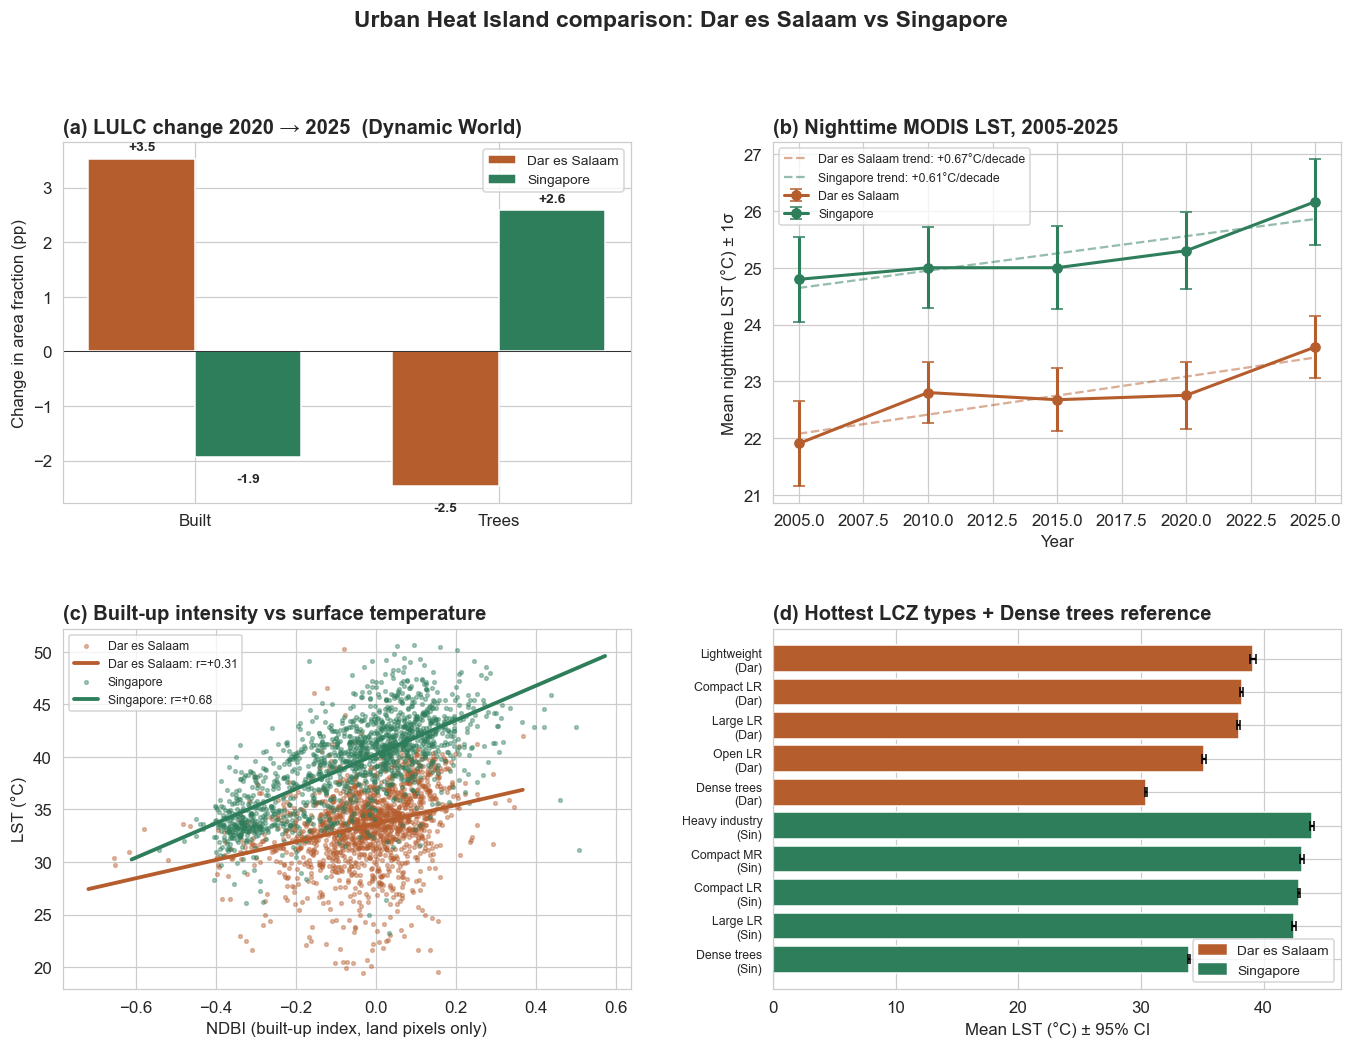

Saved: D:\uhi-dar-singapore\outputs\figures\06_poster_dashboard.png


In [9]:
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.25)

# =========== Panel 1: LULC change (top-left) ===========
ax1 = fig.add_subplot(gs[0, 0])
focus_classes = ['built', 'trees']
bar_data = pivot[pivot['class'].isin(focus_classes)].copy()
bar_data['class_year'] = bar_data['class'] + '\n' + bar_data.index.astype(str)

x = np.arange(len(focus_classes))
width = 0.35
for i, city in enumerate(['Dar es Salaam', 'Singapore']):
    sub = bar_data[bar_data.city == city].sort_values('class')
    deltas = sub['delta_pp'].values
    ax1.bar(x + (i-0.5)*width, deltas, width, label=city, color=COLORS[city])
    for j, d in enumerate(deltas):
        ax1.text(x[j] + (i-0.5)*width, d + (0.15 if d > 0 else -0.45),
                 f'{d:+.1f}', ha='center', fontsize=9, fontweight='bold')

ax1.axhline(0, color='black', lw=0.5)
ax1.set_xticks(x)
ax1.set_xticklabels([c.capitalize() for c in focus_classes])
ax1.set_ylabel('Change in area fraction (pp)')
ax1.set_title('(a) LULC change 2020 → 2025  (Dynamic World)', loc='left')
ax1.legend(loc='upper right', fontsize=9)

# =========== Panel 2: Night LST trend (top-right) ===========
ax2 = fig.add_subplot(gs[0, 1])
stats = pd.read_csv(TABLES / '03_lst_stats.csv')
for city_code, color, label in [('dar', COLORS['Dar es Salaam'], 'Dar es Salaam'),
                                 ('sgp', COLORS['Singapore'],    'Singapore')]:
    sub = stats[(stats.city == city_code) & (stats.tod == 'night')].sort_values('year')
    ax2.errorbar(sub['year'], sub['mean'], yerr=sub['std'],
                 marker='o', capsize=4, lw=2, color=color, label=label)
    # Linear fit
    from scipy.stats import linregress
    reg = linregress(sub['year'], sub['mean'])
    x_ = np.array(sub['year'])
    ax2.plot(x_, reg.intercept + reg.slope*x_, ls='--', color=color, alpha=0.5,
             label=f'{label} trend: {reg.slope*10:+.2f}°C/decade')

ax2.set_xlabel('Year')
ax2.set_ylabel('Mean nighttime LST (°C) ± 1σ')
ax2.set_title('(b) Nighttime MODIS LST, 2005-2025', loc='left')
ax2.legend(fontsize=8, loc='best')

# =========== Panel 3: NDBI-LST correlation (bottom-left) ===========
ax3 = fig.add_subplot(gs[1, 0])
samples = pd.read_csv(TABLES / '04b_pixel_samples.csv')
for city, color in COLORS.items():
    sub = samples[(samples.city == city) & (~samples['MNDWI'].isna())]
    sub = sub[sub['MNDWI'] <= 0]  # land only
    sample = sub.sample(min(1500, len(sub)), random_state=0)
    ax3.scatter(sample['NDBI'], sample['LST'], s=6, alpha=0.4, color=color, label=city)
    # Regression line
    from scipy.stats import pearsonr, linregress as lr
    r, _ = pearsonr(sub['NDBI'], sub['LST'])
    reg = lr(sub['NDBI'], sub['LST'])
    x_ = np.linspace(sub['NDBI'].min(), sub['NDBI'].max(), 50)
    ax3.plot(x_, reg.intercept + reg.slope*x_, lw=2.5, color=color,
             label=f'{city}: r={r:+.2f}')

ax3.set_xlabel('NDBI (built-up index, land pixels only)')
ax3.set_ylabel('LST (°C)')
ax3.set_title('(c) Built-up intensity vs surface temperature', loc='left')
ax3.legend(fontsize=8, loc='upper left')

# =========== Panel 4: LCZ ranking (bottom-right) ===========
ax4 = fig.add_subplot(gs[1, 1])

# For each city, take top 4 warmest urban LCZ + Dense trees as reference
def top_lcz(city, n=4):
    urban_types = ['Compact HR','Compact MR','Compact LR','Open HR','Open MR',
                   'Open LR','Lightweight','Large LR','Heavy industry','Sparsely built','Bare paved']
    sub = lcz[(lcz.city == city) & (lcz.label.isin(urban_types))].sort_values('mean', ascending=False)
    return sub.head(n)

plot_rows = []
for city in ['Dar es Salaam', 'Singapore']:
    plot_rows.append(top_lcz(city, 4).assign(city=city))
    # Add Dense trees as reference (cool baseline)
    tr = lcz[(lcz.city == city) & (lcz.label == 'Dense trees')]
    if len(tr):
        plot_rows.append(tr.assign(city=city))
plot_df = pd.concat(plot_rows, ignore_index=True)

# Horizontal bar: city × LCZ
y_positions = []
bar_colors = []
labels = []
for i, row in plot_df.iterrows():
    y_positions.append(i)
    bar_colors.append(COLORS[row['city']])
    labels.append(f"{row['label']}\n({row['city'][:3]})")

ax4.barh(range(len(plot_df)), plot_df['mean'], color=bar_colors,
         xerr=plot_df['ci95'], capsize=3)
ax4.set_yticks(range(len(plot_df)))
ax4.set_yticklabels(labels, fontsize=8)
ax4.set_xlabel('Mean LST (°C) ± 95% CI')
ax4.set_title('(d) Hottest LCZ types + Dense trees reference', loc='left')
ax4.invert_yaxis()

# Custom legend for panel 4
handles = [mpatches.Patch(color=c, label=n) for n, c in COLORS.items()]
ax4.legend(handles=handles, fontsize=9, loc='lower right')

plt.suptitle('Urban Heat Island comparison: Dar es Salaam vs Singapore',
             fontsize=15, fontweight='bold', y=1.00)
plt.savefig(FIGURES / '06_poster_dashboard.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {(FIGURES / "06_poster_dashboard.png").resolve()}')

## 6. Figure 2 — Cooling benefit of urban trees (policy-facing)

A clean single-panel figure for the poster's "so what" section.

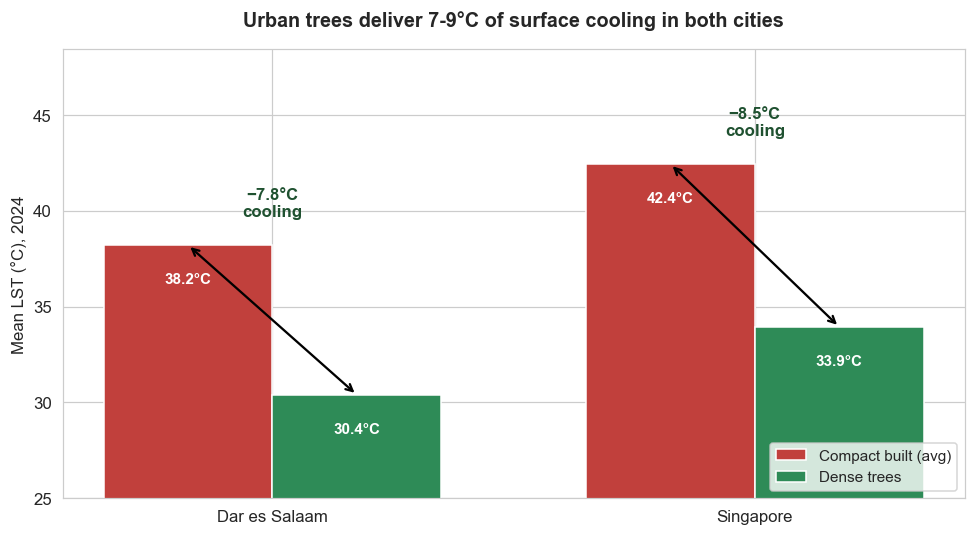

Saved: D:\uhi-dar-singapore\outputs\figures\06_cooling_benefit.png


In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

# Build: city, {built_avg, trees, delta}
data = []
for city in ['Dar es Salaam', 'Singapore']:
    built_types = ['Compact HR', 'Compact MR', 'Compact LR']
    built_means = [get_lcz_mean(city, t) for t in built_types]
    built_means = [m for m in built_means if m is not None]
    trees = get_lcz_mean(city, 'Dense trees')
    if built_means and trees:
        data.append({
            'city': city,
            'Compact built': np.mean(built_means),
            'Dense trees':   trees,
            'cooling':       np.mean(built_means) - trees,
        })

x = np.arange(2)
width = 0.35
cities = [d['city'] for d in data]
built_vals = [d['Compact built'] for d in data]
tree_vals  = [d['Dense trees']   for d in data]

b1 = ax.bar(x - width/2, built_vals, width, label='Compact built (avg)', color='#C1403C')
b2 = ax.bar(x + width/2, tree_vals,  width, label='Dense trees',         color='#2E8B57')

# Annotate cooling benefit with arrow and value
for i, d in enumerate(data):
    x_arrow = i
    y_top = max(built_vals[i], tree_vals[i]) + 1.5
    ax.annotate('', xy=(x_arrow - width/2, built_vals[i]),
                xytext=(x_arrow + width/2, tree_vals[i]),
                arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
    ax.text(x_arrow, y_top, f"−{d['cooling']:.1f}°C\ncooling",
            ha='center', fontsize=11, fontweight='bold', color='#1F5130')

# Bar value labels
for bars, vals in [(b1, built_vals), (b2, tree_vals)]:
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v - 2, f'{v:.1f}°C',
                ha='center', color='white', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(cities)
ax.set_ylabel('Mean LST (°C), 2024')
ax.set_title('Urban trees deliver 7-9°C of surface cooling in both cities',
             fontsize=13, pad=15)
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(25, max(built_vals) + 6)

plt.tight_layout()
plt.savefig(FIGURES / '06_cooling_benefit.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {(FIGURES / "06_cooling_benefit.png").resolve()}')

## 7. Figure 3 — Tale of two cities (conceptual contrast)

A conceptual figure highlighting how the same UHI phenomenon manifests differently in each city.

C:\Users\SantaTrinitas\AppData\Local\Temp\ipykernel_20076\2381501192.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg = sub.groupby('category').apply(
C:\Users\SantaTrinitas\AppData\Local\Temp\ipykernel_20076\2381501192.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg = sub.groupby('category').apply(


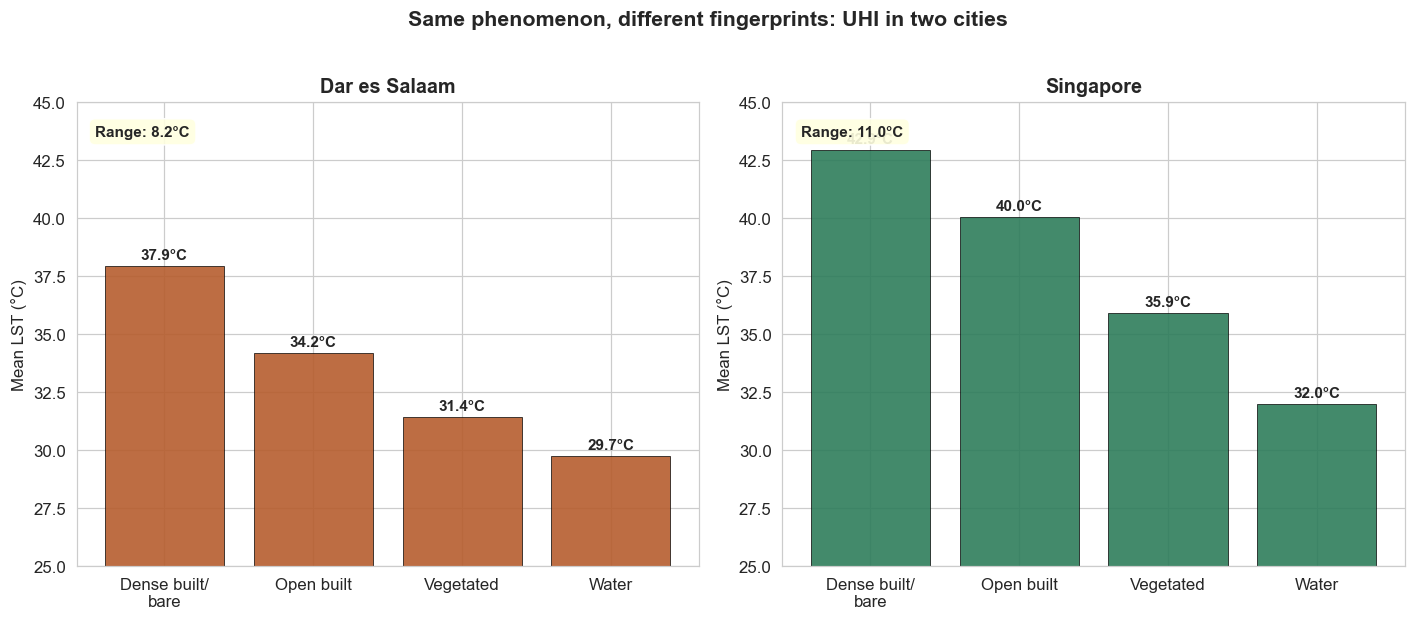

Saved: D:\uhi-dar-singapore\outputs\figures\06_two_cities_story.png


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, city in zip([ax1, ax2], ['Dar es Salaam', 'Singapore']):
    sub = lcz[lcz.city == city].copy()
    # Broad categories for simplicity
    def categorize(label):
        if label in ['Compact HR','Compact MR','Compact LR','Lightweight',
                     'Large LR','Heavy industry','Bare paved','Bare soil']:
            return 'Dense built/\nbare'
        if label in ['Open HR','Open MR','Open LR','Sparsely built']:
            return 'Open built'
        if label in ['Dense trees','Scattered trees','Bush/scrub','Low plants']:
            return 'Vegetated'
        if label == 'Water':
            return 'Water'
        return None

    sub['category'] = sub['label'].map(categorize)
    sub = sub.dropna(subset=['category'])

    # Weighted mean per category (by pixel count)
    agg = sub.groupby('category').apply(
        lambda d: np.average(d['mean'], weights=d['count'])
    ).reset_index()
    agg.columns = ['category', 'mean_LST']

    order = ['Dense built/\nbare', 'Open built', 'Vegetated', 'Water']
    agg['category'] = pd.Categorical(agg['category'], categories=order, ordered=True)
    agg = agg.sort_values('category')

    bars = ax.bar(agg['category'], agg['mean_LST'], color=COLORS[city], alpha=0.9,
                  edgecolor='black', lw=0.5)
    # Value labels
    for bar, v in zip(bars, agg['mean_LST']):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.3, f'{v:.1f}°C',
                ha='center', fontsize=10, fontweight='bold')

    ax.set_title(city, fontsize=13)
    ax.set_ylabel('Mean LST (°C)')
    ax.set_ylim(25, 45)

    # Add the intra-city range as annotation
    rng = agg['mean_LST'].max() - agg['mean_LST'].min()
    ax.text(0.03, 0.95, f'Range: {rng:.1f}°C', transform=ax.transAxes,
            fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.9),
            verticalalignment='top')

plt.suptitle('Same phenomenon, different fingerprints: UHI in two cities',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / '06_two_cities_story.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {(FIGURES / "06_two_cities_story.png").resolve()}')

## 8. Final summary — what's on your poster

### The three-sentence abstract

*"We compared Urban Heat Island patterns in Dar es Salaam (rapidly urbanizing) and Singapore (actively greening) using 20 years of satellite thermal imagery. Both cities show nighttime warming of +0.6°C per decade, but diverge sharply in spatial structure: Dar's heat is concentrated in informal settlements (Lightweight LCZ at 39°C), while Singapore's heat is in its dense commercial-industrial core (up to 44°C). Dense urban trees cool both cities by ~7-8°C versus their built-up counterparts, suggesting a transferable policy finding across tropical urban contexts."*

### Key numbers that should appear on the poster

From the headline table:

- **Night warming:** Dar +0.67°C/decade, Singapore +0.61°C/decade (both p<0.05)
- **Built-up change:** Dar +3.5pp, Singapore −1.9pp (2020→2025)
- **Tree change:** Dar −2.5pp, Singapore +2.6pp (Singapore is actually greening)
- **NDBI-LST correlation:** Dar r=+0.31, Singapore r=+0.69 (stronger signal in Singapore reflects cleaner urban morphology)
- **Intra-city thermal range:** Dar 9.4°C, Singapore 12.0°C
- **Cooling benefit of dense trees:** Dar 7.8°C, Singapore 8.5°C

### Recommended poster layout

```
┌────────────────────────────────────────────────────────────┐
│ Title: Urban Heat Island in Dar es Salaam vs Singapore     │
│ Team names, mentor, affiliations                            │
├────────────────────┬───────────────────────────────────────┤
│ Introduction &      │   Figure 1: 4-panel dashboard         │
│ hypothesis          │   (06_poster_dashboard.png)           │
│ [~150 words]        │                                       │
│                    │                                       │
│ Methods summary     │                                       │
│ [~100 words]        │                                       │
├────────────────────┼───────────────────────────────────────┤
│ Figure 2:           │   Figure 3:                           │
│ Cooling benefit     │   Two cities story                    │
│ (06_cooling_        │   (06_two_cities_story.png)           │
│  benefit.png)       │                                       │
├────────────────────┴───────────────────────────────────────┤
│ Key findings (3-5 bullet points)                            │
│                                                             │
│ Policy implications (2-3 bullet points)                     │
│                                                             │
│ References + data sources + GitHub link                     │
└────────────────────────────────────────────────────────────┘
```

### Caveats to acknowledge (at least one)

- Sentinel-2 and Landsat scenes are cloud-filtered; Dar suffers more from tropical cloud cover and has smaller effective sample sizes
- MODIS 1km resolution smooths fine-scale hotspots
- 2020 was La Niña (globally cool), 2015 was El Niño start — year-to-year noise on 20-year trend
- Day LST trend came out negative (likely 2025 incomplete data artifact); night trend is the defensible result
- WUDAPT LCZ map dates to ~2022, so rapid Dar growth since then may not be fully captured

### Next steps (for your writeup's future-work section)

- Seasonal breakdown (dry vs wet monsoon) to isolate solar irradiance effects
- Overlay population density (WorldPop) for climate-justice analysis
- ML-based future projection to 2040 using CA-ANN
- Ground-truth validation against Dar/SGP meteorological stations